In [50]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from utils import get_eval_stats
import scipy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Saved figure to: /home/shai/NeuripsProtein2026/Figures/scaling_and_latency_tradeoff_fullwidth.pdf


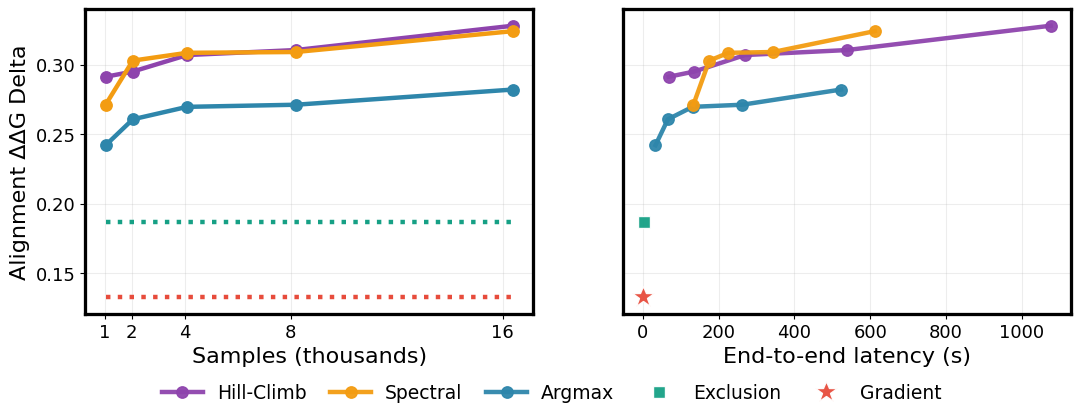

Matched timing runs: 15


,method_label,budget,avg_latency_s,alignment,normalized_file
0,Argmax,1024,33.569321,0.241981,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
1,Argmax,2048,66.243387,0.260658,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
2,Argmax,4096,131.384398,0.269639,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
3,Argmax,8192,262.226831,0.271158,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
4,Argmax,16384,523.212505,0.282102,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
5,Hill-Climb,1024,68.323907,0.291297,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
6,Hill-Climb,2048,135.596910,0.295059,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
7,Hill-Climb,4096,269.850150,0.306948,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
8,Hill-Climb,8192,538.717330,0.310547,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...
9,Hill-Climb,16384,1076.081709,0.328076,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...


,method_label,avg_latency_s,alignment,eval_csv,timings_csv,budget
exclusion,Exclusion,3.671542,0.18662,pretrained_test_ddg_bon_N=1_feedbacksteps=5_fe...,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,20
gradient,Gradient,1.583833,0.13242,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,pretrained_test_ddg_bon_N=1_feedbacksteps=1_fe...,20


In [51]:
from pathlib import Path
import ast
import re
from collections import defaultdict

# Tradeoff plot: latency (timings CSVs) vs alignment delta used in Fig. 4 scaling
neurips_dir = Path("/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/neurips")
timings_dir = neurips_dir / "timings"


def normalize_filename(name: str) -> str:
    # Some spectral files in timings have an extra underscore before .csv
    return name.replace("_.csv", ".csv")


def extract_int_from_name(name: str, key: str):
    m = re.search(rf"{re.escape(key)}=([-]?\d+)", name)
    return int(m.group(1)) if m else None


def extract_feedback_method(name: str):
    m = re.search(r"feedbackmethod=([^_]+)", name)
    return m.group(1) if m else None


def pretty_method(name: str):
    return {
        "max-mask": "Argmax",
        "spectral": "Spectral",
        "hill-climb": "Hill-Climb",
        "exclusion": "Exclusion",
        "gradient": "Gradient",
    }.get(name, name or "unknown")


def extract_budget(name: str):
    masks = extract_int_from_name(name, "masks")
    if masks is not None:
        return masks
    hcits = extract_int_from_name(name, "hcits")
    if hcits is not None:
        return hcits
    if extract_feedback_method(name) == "gradient":
        return extract_int_from_name(name, "maxspecorder")
    return None


# --- Match ``neurips_figures4`` scaling plot: baselines are constant vs sample budget; same file choice + pooling. ---
traj_col = "spec_trajectory"
target_protein = None  # set to a PDB stem (no .pdb) to mirror fig4 single-protein mode
BASELINE_METHODS = frozenset({"exclusion", "gradient"})


def reward_mean_se_first_feedback_fig4(df: pd.DataFrame) -> tuple[float, float]:
    """Same pooling as fig4 ``reward_mean_se_first_feedback`` (mean of per-protein means, combined SEM)."""
    df_work = df
    if target_protein is not None:
        df_work = df_work[df_work["protein_name"] == target_protein + ".pdb"]
    if traj_col not in df_work.columns or "protein_name" not in df_work.columns:
        return float("nan"), float("nan")

    protein_names = sorted(set(df_work["protein_name"]))
    cluster_means = []
    std_errors = []
    for p in protein_names:
        df_p = df_work[df_work["protein_name"] == p]
        deltas = []
        for lst in df_p[traj_col].tolist():
            traj_p = np.asarray(eval(lst), dtype=float).ravel()
            if traj_p.size >= 2:
                deltas.append(float(traj_p[1] - traj_p[0]))
        if not deltas:
            continue
        deltas = np.asarray(deltas, dtype=float)
        cluster_means.append(float(np.mean(deltas)))
        std_errors.append(float(scipy.stats.sem(deltas)))

    if not cluster_means:
        return float("nan"), float("nan")

    n_proteins = len(cluster_means)
    std_errors = np.asarray(std_errors, dtype=float)
    return float(np.mean(cluster_means)), float(np.sqrt(np.sum(std_errors**2)) / n_proteins)


def aggregate_scaling_rows_fig4(*, csv_paths, target_order=20, target_bon_n=1):
    """Port of fig4 ``aggregate_neurips_budget_curve_from_current_data`` (row selection + common proteins)."""
    grouped_files = defaultdict(list)

    for path in csv_paths:
        name = path.name
        if not name.startswith("pretrained_test"):
            continue
        method = extract_feedback_method(name)
        budget = extract_budget(name)
        order = extract_int_from_name(name, "maxspecorder")
        bon_n = extract_int_from_name(name, "bon_N")

        if method is None:
            continue

        if method == "exclusion":
            budget = 20
            if order != target_order or bon_n != target_bon_n:
                continue
        elif method == "gradient":
            budget = extract_budget(name)
            if budget is None:
                continue
            if order != target_order or bon_n != target_bon_n:
                continue
        else:
            if budget is None:
                continue
            if order != target_order or bon_n != target_bon_n:
                continue

        grouped_files[(method, budget)].append(path)

    def _preferred_csv(paths):
        if len(paths) <= 1:
            return paths
        return [min(paths, key=lambda p: extract_int_from_name(p.name, "feedbacksteps"))]

    for key in list(grouped_files.keys()):
        grouped_files[key] = _preferred_csv(grouped_files[key])

    selected_paths = sorted({p for files in grouped_files.values() for p in files})
    common_proteins = None
    for p in selected_paths:
        df = pd.read_csv(p)
        proteins = set(df["protein_name"].dropna().astype(str).tolist())
        common_proteins = proteins if common_proteins is None else (common_proteins & proteins)

    if target_protein is not None:
        target_name = target_protein + ".pdb"
        common_proteins = {target_name} if (common_proteins is None or target_name in common_proteins) else set()

    common_proteins = set() if common_proteins is None else common_proteins

    rows = []
    for (method, budget), files in sorted(grouped_files.items(), key=lambda x: (x[0][0], x[0][1])):
        per_file_y = []
        per_file_se = []

        for f in sorted(files):
            df = pd.read_csv(f)
            if common_proteins:
                df = df[df["protein_name"].astype(str).isin(common_proteins)].copy()
            else:
                df = df.iloc[0:0].copy()

            if len(df) == 0:
                continue

            y_f, se_f = reward_mean_se_first_feedback_fig4(df)
            per_file_y.append(float(y_f))
            per_file_se.append(float(se_f))

        if len(per_file_y) == 0:
            continue

        arr_y = np.asarray(per_file_y, dtype=float)
        arr_se = np.asarray(per_file_se, dtype=float)
        y = float(np.mean(arr_y))
        se = float(np.sqrt(np.sum(arr_se**2)) / len(arr_se))

        rows.append(
            {
                "method": method,
                "method_label": pretty_method(method),
                "budget": budget,
                "traj_final": y,
                "se": se,
                "n_files": len(per_file_y),
                "paths": [p.name for p in sorted(files)],
            }
        )

    return rows


def resolve_timings_csv_for_eval(timings_directory: Path, eval_csv_name: str) -> Path | None:
    """Map an eval-results CSV name to a timings CSV under ``timings_directory``.

    Usually the basename matches exactly. Two common mismatches handled here:

    - Spectral runs sometimes ship as ``*_rmax=False_.csv`` vs ``*_rmax=False.csv``.
    - Eval exports may use a different ``feedbacksteps=`` than timings (Fig. 4 aggregation
      can pick ``feedbacksteps=5`` CSVs while timings only exist for ``feedbacksteps=1``).
    """
    stem = Path(eval_csv_name).name
    candidates = [
        timings_directory / stem,
        timings_directory / stem.replace(".csv", "_.csv"),
        timings_directory / stem.replace("_.csv", ".csv"),
    ]
    seen: set[str] = set()
    for c in candidates:
        key = str(c)
        if key in seen:
            continue
        seen.add(key)
        if c.is_file():
            return c

    if not timings_directory.is_dir():
        return None

    method = extract_feedback_method(stem)
    if method is None:
        return None

    bon_want = extract_int_from_name(stem, "bon_N")
    order_want = extract_int_from_name(stem, "maxspecorder")
    fb_want = extract_int_from_name(stem, "feedbacksteps")

    masks_want = extract_int_from_name(stem, "masks")
    hcits_want = extract_int_from_name(stem, "hcits")

    loose: list[Path] = []
    for p in timings_directory.glob("*.csv"):
        n = p.name
        if not n.startswith("pretrained_test"):
            continue
        if extract_feedback_method(n) != method:
            continue
        if bon_want is not None and extract_int_from_name(n, "bon_N") != bon_want:
            continue
        if order_want is not None and extract_int_from_name(n, "maxspecorder") != order_want:
            continue
        if masks_want is not None and extract_int_from_name(n, "masks") != masks_want:
            continue
        if hcits_want is not None and extract_int_from_name(n, "hcits") != hcits_want:
            continue
        loose.append(p)

    if not loose:
        return None

    # Prefer timings from the same feedback-step count when that file exists.
    if fb_want is not None:
        exact_fb = [
            q for q in loose
            if extract_int_from_name(q.name, "feedbacksteps") == fb_want
        ]
        if len(exact_fb) == 1:
            return exact_fb[0]
        if len(exact_fb) > 1:
            return sorted(exact_fb)[0]

    # Otherwise typically use the smallest-numbered timings export available.
    loose_sorted = sorted(
        loose,
        key=lambda q: extract_int_from_name(q.name, "feedbacksteps") or 10**9,
    )
    return loose_sorted[0]


def mean_latency_seconds(df_t: pd.DataFrame) -> float | None:
    if "protein_sampling_wall_time_s" not in df_t.columns:
        return None
    if "protein_name" in df_t.columns:
        per_prot = df_t.groupby("protein_name")["protein_sampling_wall_time_s"].mean()
        return float(per_prot.mean())
    return float(df_t["protein_sampling_wall_time_s"].mean())


def fig4_constant_baseline_tradeoff_points(scaling_rows, timings_directory: Path):
    """One (latency, alignment) per baseline method; alignment = fig4 horizontal baseline (last budget point)."""

    def _hline_y(method: str) -> tuple[dict | None, float | None]:
        pts = sorted([r for r in scaling_rows if r["method"] == method], key=lambda r: r["budget"])
        if not pts:
            return None, None
        r_pick = pts[-1]
        y = float(r_pick["traj_final"])
        return r_pick, y

    out = {}
    for method in sorted(BASELINE_METHODS):
        r_last, y_h = _hline_y(method)
        if r_last is None or y_h is None or not np.isfinite(y_h):
            print(f"Warning: no Fig.4 scaling row for baseline {method!r}")
            continue
        eval_name = r_last["paths"][0]
        tpath = resolve_timings_csv_for_eval(timings_directory, eval_name)
        if tpath is None:
            print(f"Warning: no timings CSV for Fig.4 baseline {method!r} (eval {eval_name!r})")
            continue
        lat = mean_latency_seconds(pd.read_csv(tpath))
        if lat is None or not np.isfinite(lat):
            print(f"Warning: could not read latency from {tpath}")
            continue
        out[method] = {
            "method_label": pretty_method(method),
            "avg_latency_s": lat,
            "alignment": y_h,
            "eval_csv": eval_name,
            "timings_csv": tpath.name,
            "budget": r_last["budget"],
        }
    return out


def first_feedback_alignment_mean(df: pd.DataFrame) -> float:
    if "spec_trajectory" not in df.columns:
        return np.nan

    traj = (
        df["spec_trajectory"]
        .dropna()
        .apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    )
    traj = traj[traj.apply(lambda x: isinstance(x, (list, tuple)) and len(x) > 1)]
    if traj.empty:
        return np.nan

    deltas = traj.apply(lambda t: float(t[1]) - float(t[0]))

    # Match Fig. 4 aggregation style: average across proteins (if names exist)
    if "protein_name" in df.columns:
        protein_name = df.loc[deltas.index, "protein_name"]
        protein_means = deltas.groupby(protein_name).mean()
        return float(protein_means.mean()) if len(protein_means) else np.nan

    return float(deltas.mean())


# Build lookup of alignment values from eval CSVs
align_by_file = {}
for p in neurips_dir.glob("pretrained_test*.csv"):
    name = normalize_filename(p.name)
    if extract_int_from_name(name, "bon_N") != 1:
        continue
    df_eval = pd.read_csv(p)
    align_by_file[name] = first_feedback_alignment_mean(df_eval)


# Aggregate timings + join alignment for corresponding files
rows = []
for p in timings_dir.glob("pretrained_test*.csv"):
    original_name = p.name
    normalized_name = normalize_filename(original_name)

    if normalized_name not in align_by_file:
        continue

    df_t = pd.read_csv(p)
    if "protein_sampling_wall_time_s" not in df_t.columns:
        continue

    method = extract_feedback_method(normalized_name)
    budget = extract_budget(normalized_name)

    # Average latency of proteins in this run
    if "protein_name" in df_t.columns:
        per_protein_latency = df_t.groupby("protein_name")["protein_sampling_wall_time_s"].mean()
        avg_latency_s = float(per_protein_latency.mean())
    else:
        avg_latency_s = float(df_t["protein_sampling_wall_time_s"].mean())

    rows.append(
        {
            "file": original_name,
            "normalized_file": normalized_name,
            "method": method,
            "method_label": pretty_method(method),
            "budget": budget,
            "avg_latency_s": avg_latency_s,
            "alignment": align_by_file[normalized_name],
        }
    )

tradeoff_df = pd.DataFrame(rows).dropna(subset=["avg_latency_s", "alignment"])
tradeoff_df = tradeoff_df.sort_values(["method_label", "budget"], na_position="last").reset_index(drop=True)

# Fig. 4 scaling aggregation (same CSV selection + ``reward_mean_se_first_feedback`` pooling as that notebook).
_all_neurips_csvs = sorted(neurips_dir.glob("*.csv"))
fig4_csv_paths = [
    p
    for p in _all_neurips_csvs
    if p.name.startswith("pretrained_test") and extract_int_from_name(p.name, "bon_N") == 1
]
scaling_rows_fig4 = aggregate_scaling_rows_fig4(csv_paths=fig4_csv_paths)
baseline_tradeoff = fig4_constant_baseline_tradeoff_points(scaling_rows_fig4, timings_dir)

method_colors = {
    "Argmax": "#2E86AB",
    "Spectral": "#F39C12",
    "Hill-Climb": "#8E44AD",
    "Exclusion": "#16A085",
    "Gradient": "#E74C3C",
}

from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

LINE_W = 3.2
MARKER_S = 8.2
AXIS_LABEL_FS = 16
TICK_LABEL_FS = 13
LEGEND_FS = 13.5
STAR_MARKER_SCALE = 2

def marker_size_for(method_label: str, marker: str) -> float:
    # Tune star size to visually match square marker footprint.
    return MARKER_S * STAR_MARKER_SCALE if marker == "*" else MARKER_S


# --- Larger, two-panel layout with shared legend ---
FIG_W_FULL_PAGE_IN = 10.6
fig, (ax_scaling, ax_lat) = plt.subplots(
    1,
    2,
    figsize=(FIG_W_FULL_PAGE_IN, FIG_W_FULL_PAGE_IN * 0.35),
    sharey=True,
)

# ------- Left: search-budget scaling (same conventions as neurips_figures4.csv plot) -------
method_to_pts = {}
for method in sorted(set(r["method"] for r in scaling_rows_fig4)):
    pts = sorted(
        [r for r in scaling_rows_fig4 if r["method"] == method],
        key=lambda r: r["budget"],
    )
    if pts:
        method_to_pts[method] = pts

ordered_methods = sorted(
    method_to_pts,
    key=lambda m: method_to_pts[m][-1]["traj_final"],
    reverse=True,
)
scaled_budgets = sorted(
    {r["budget"] for r in scaling_rows_fig4 if r["method"] not in BASELINE_METHODS}
)

for method in ordered_methods:
    pts = method_to_pts[method]
    label = pts[0]["method_label"]
    color = method_colors.get(label, "#555555")
    xs = np.asarray([r["budget"] for r in pts], dtype=float)
    xs_k = xs / 1000.0
    ys = np.asarray([r["traj_final"] for r in pts], dtype=float)

    if method in BASELINE_METHODS:
        y = float(ys[-1])
        if len(scaled_budgets) > 0:
            x_min = float(min(scaled_budgets)) / 1000.0
            x_max = float(max(scaled_budgets)) / 1000.0
        else:
            x_min = float(xs_k.min())
            x_max = float(xs_k.max())
        ax_scaling.hlines(
            y,
            x_min,
            x_max,
            label=label,
            color=color,
            linewidth=LINE_W,
            linestyle=":",
            zorder=4,
        )
        continue

    ax_scaling.plot(
        xs_k,
        ys,
        label=label,
        color=color,
        linewidth=LINE_W,
        marker="o",
        markersize=MARKER_S,
        markeredgecolor=color,
        markeredgewidth=1.0,
        solid_capstyle="round",
        zorder=5,
    )

for _sp in ax_scaling.spines.values():
    _sp.set_linewidth(2.35)

# ax_scaling.set_xscale("log", base=10)
ax_scaling.set_xlabel("Samples (thousands)", fontsize=AXIS_LABEL_FS)
ax_scaling.set_ylabel("Alignment ΔΔG Delta", fontsize=AXIS_LABEL_FS)
ax_scaling.tick_params(axis="both", labelsize=TICK_LABEL_FS)
ax_scaling.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Cleaner x-axis ticks in thousands (1, 2, 4, 8, 16)
if len(scaled_budgets) > 0:
    ax_scaling.set_xticks(np.asarray(scaled_budgets, dtype=float) // 1000.0)

ax_scaling.grid(True, which="both", alpha=0.22)

# ------- Right: latency vs alignment -------
plot_df = tradeoff_df[~tradeoff_df["method"].isin(BASELINE_METHODS)].copy()

for method_label, grp in plot_df.groupby("method_label", sort=False):
    grp = grp.sort_values("budget", na_position="last")
    color = method_colors.get(method_label, "#777777")

    # Use uniform styling across all methods
    lw = LINE_W
    ms = MARKER_S
    mew = 1.0

    ax_lat.plot(
        grp["avg_latency_s"],
        grp["alignment"],
        marker="o",
        linewidth=lw,
        markersize=ms,
        markeredgewidth=mew,
        markeredgecolor=color,
        label=method_label,
        color=color,
        alpha=0.95,
        zorder=6,
    )

for method_key in ("gradient", "exclusion"):
    info = baseline_tradeoff.get(method_key)
    if info is None:
        continue
    lbl = info["method_label"]
    color = method_colors.get(lbl, "#777777")
    marker = "*" if method_key == "gradient" else "s"
    ms = marker_size_for(lbl, marker)
    ax_lat.plot(
        [info["avg_latency_s"]],
        [info["alignment"]],
        marker=marker,
        linestyle="None",
        markersize=ms,
        markeredgewidth=1.0,
        markeredgecolor="white",
        label=lbl,
        color=color,
        alpha=0.95,
        zorder=6,
    )

for _sp in ax_lat.spines.values():
    _sp.set_linewidth(2.35)

ax_lat.set_xlabel("End-to-end latency (s)", fontsize=AXIS_LABEL_FS)
# Shared y-axis with left panel: hide duplicate y-label/ticks on right panel.
ax_lat.tick_params(axis="x", labelsize=TICK_LABEL_FS)
ax_lat.tick_params(axis="y", left=False, labelleft=False)
ax_lat.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Keep full data range visible (including Exclusion/Gradient), with slight padding
all_y = [
    *plot_df["alignment"].tolist(),
    *[v["alignment"] for v in baseline_tradeoff.values()],
]
if len(all_y) > 0:
    y_min = float(np.min(all_y))
    y_max = float(np.max(all_y))
    pad = max(0.006, 0.06 * (y_max - y_min))
    ax_lat.set_ylim(y_min - pad, y_max + pad)

ax_lat.grid(alpha=0.22)


def _handles_by_label_ordered(fig, label_order):
    """One legend entry per method: latency panel overrides scaling for duplicated labels."""
    by_lbl = {}
    for ax in reversed(fig.axes):
        h, lb = ax.get_legend_handles_labels()
        for hi, li in zip(h, lb):
            if not li or li.startswith("_"):
                continue
            if li not in by_lbl:
                by_lbl[li] = hi
    return [by_lbl[k] for k in label_order if k in by_lbl], [k for k in label_order if k in by_lbl]


legend_labels_unique = []
_seen_leg = set()
for m in ordered_methods:
    lbl = method_to_pts[m][0]["method_label"]
    if lbl not in _seen_leg:
        _seen_leg.add(lbl)
        legend_labels_unique.append(lbl)

_handles, _labels = _handles_by_label_ordered(fig, legend_labels_unique)
ncol = min(6, len(_labels))
fig.legend(
    _handles,
    _labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.125),
    ncol=ncol,
    frameon=False,
    fontsize=LEGEND_FS,
    handlelength=2.2,
    handletextpad=0.75,
    columnspacing=1.25,
)

fig.subplots_adjust(bottom=0.16, left=0.06, right=0.99, top=0.98, wspace=0.20)

output_pdf = Path.home() / "NeuripsProtein2026" / "Figures" / "scaling_and_latency_tradeoff_fullwidth.pdf"
output_pdf.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
print(f"Saved figure to: {output_pdf}")

# # Backwards-compatible name (single tradeoff pdf)
# output_pdf_tradeoff_compat = Path.home() / "NeuripsProtein2026" / "Figures" / "baseline_edit_position_latency_curve.pdf"
# output_pdf_tradeoff_compat.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(output_pdf_tradeoff_compat, format="pdf", bbox_inches="tight")
# print(f"(Also saved compat path: {output_pdf_tradeoff_compat})")


plt.show()


print(f"Matched timing runs: {len(tradeoff_df)}")
display(tradeoff_df[["method_label", "budget", "avg_latency_s", "alignment", "normalized_file"]])
if baseline_tradeoff:
    display(pd.DataFrame(baseline_tradeoff).T)